# Task #5: EDA (Features and How They Relate)

In [95]:
import os
from pathlib import Path
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.feature_selection import mutual_info_classif

# Run from the repo root whether the kernel starts in notebooks/ (VS Code default) or the root
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Working directory:", Path.cwd())

Working directory: /Users/rina/Documents/vs-code/BTT_AWS1A/AWS-1A-climate-risk-modeling-for-supply-chain-resiliency


In [96]:
daily = pd.read_csv("data/processed/tao-all2-train.csv", parse_dates=["standardized_date"]) 
monthly = pd.read_csv("data/processed/features-train.csv")

print(daily.shape)
print(monthly.shape)

(67892, 30)
(1988, 42)


In [97]:
# Data Organization before EDA visuals


# Fill missing humidity values with NaN
# Why: Originally humidity column pre 1989 had many missing values.
# We decided to fill those with zeroes in data cleaning, but if we were to plot a histogram
# here, majority of the data would be heavily skewed.
# So, by filling with NaN instead, we can better visualize the distribution of humidity values.
# E.g. plots that use .mean(), .skew(), and correlations would skip NaN and therefore,
# we'd get an accurate representation of the data.
# Cutoff is November 1989, not January: sensors arrived in Nov 1989 (DATA_CLEANING.md), and
# Jan–Oct 1989 has only 1 distinct humidity value per month, i.e. it's all mean-filled (checked in Part 3e)
has_sensor = (daily["year"] > 1989) | ((daily["year"] == 1989) & (daily["month"] >= 11))
daily['humidity'] = daily['humidity'].where(has_sensor)

# Define class order for risk categories
# Why: Pandas sorts class names alphabetically by default
# So, it'd be "Extreme Cool, Extreme Warm, Moderate Cool… "" <- puts two extremes together
# The code below sorts all classes so that every plot reads left to right (e.g. cool to warm)
CLASS_ORDER = ["Extreme Cool", "Moderate Cool", "Neutral", "Moderate Warm", "Extreme Warm"]
daily["risk_class"] = pd.Categorical(daily["risk_class"], categories=CLASS_ORDER, ordered=True)
monthly["target_risk"] = pd.Categorical(monthly["target_risk"], categories=CLASS_ORDER, ordered=True)


## Part 1: Summary of Raw Data

In [98]:
RAW =  ["zonal_wind", "meridional_wind", "air_temp", "ss_temp", "humidity"] # Raw features

summary = daily[RAW].describe().T # Summary statistics: .T flips the table so each variable is a row. Why: easier to read with 5 variables.
summary["skew"] = daily[RAW].skew() # Skewness
summary.round(2) # Round to 2 decimal places

,count,mean,std,min,25%,50%,75%,max,skew
zonal_wind,67892.0,-3.25,3.12,-12.20,-5.50,-3.60,-1.80,12.50,0.96
meridional_wind,67892.0,0.69,2.79,-10.80,-1.10,0.73,2.40,11.40,-0.04
air_temp,67892.0,26.60,1.83,17.05,25.77,26.99,27.90,31.48,-1.12
ss_temp,67892.0,27.42,2.20,17.35,26.23,28.02,29.13,31.09,-1.08
humidity,54358.0,81.41,3.54,54.00,79.91,81.52,82.80,99.50,0.13


## Part 2: Distributions of Raw Features

Checks for skewness and outliers.

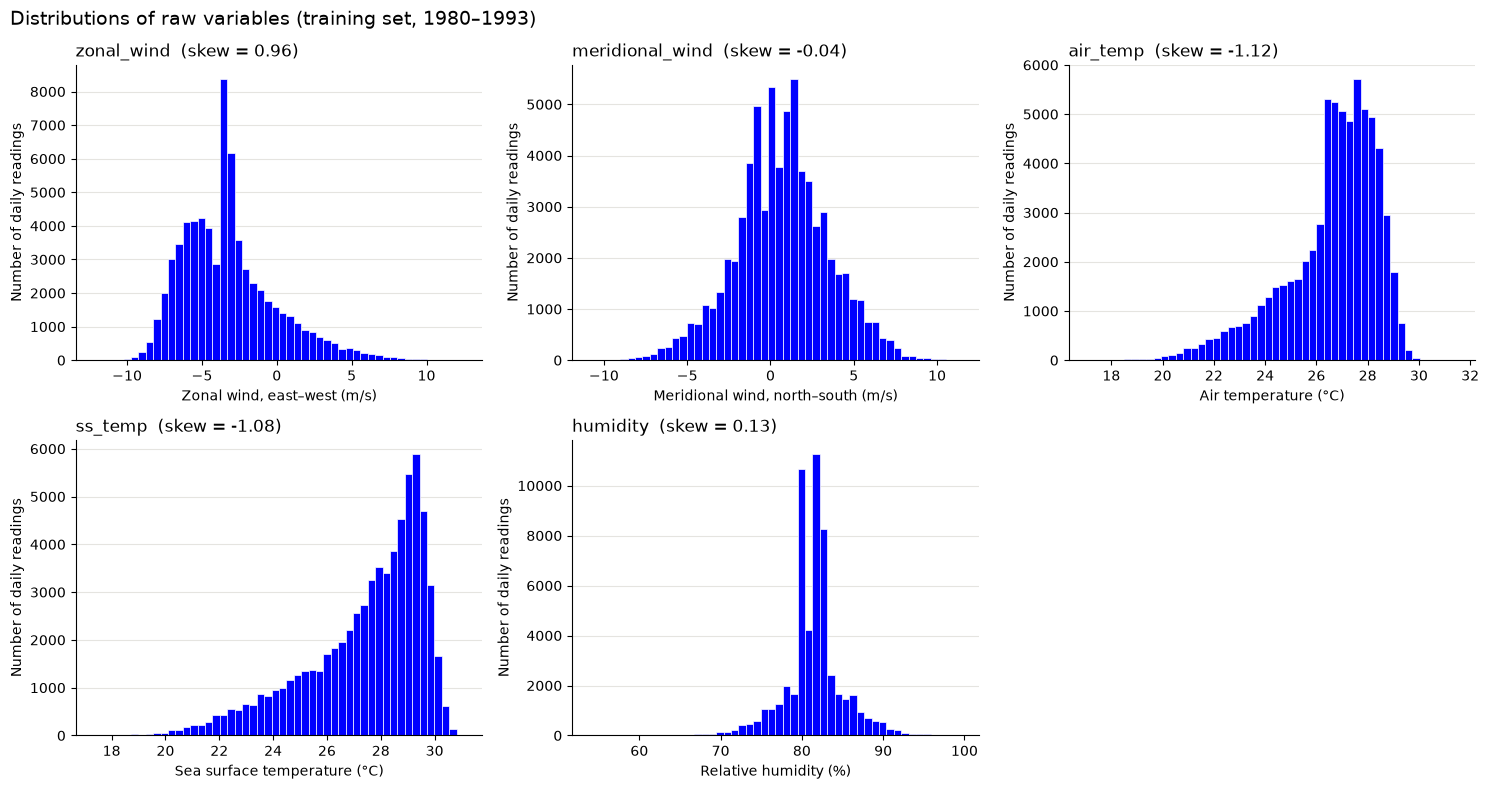

In [99]:
# Making Dictionary for every variable and their units
UNITS = {
    "zonal_wind": "Zonal wind, east–west (m/s)",
    "meridional_wind": "Meridional wind, north–south (m/s)",
    "air_temp": "Air temperature (°C)",
    "ss_temp": "Sea surface temperature (°C)",
    "humidity": "Relative humidity (%)",
}

# Creating subplots
fig,axes = plt.subplots(2, 3,figsize=(15,8))

# Flattening the axes array
# Why: to make it easier to iterate over by creating a 1D array
axes = axes.flatten()

# Iterating over the variables and their corresponding axes
for col, ax in zip(RAW, axes):
    # Drops missing any values.
    # Why: matplotlib cant put NaN in the histogram
    values = daily[col].dropna()
    
    ax.hist(values, bins=50, color='blue', edgecolor="white", linewidth=0.5)
    ax.set_title(f"{col}  (skew = {values.skew():.2f})", loc="left")
    ax.set_xlabel(UNITS[col])
    ax.set_ylabel("Number of daily readings")

    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
    ax.set_axisbelow(True)

axes[-1].axis("off")  # 5 variables, 6 slots: hide the empty one

fig.suptitle("Distributions of raw variables (training set, 1980–1993)", x=0.01, ha="left", fontsize=14)
plt.tight_layout()
plt.show()




## Part 3: Building Physical Features

**Why build features?** The raw sensor columns describe the ocean in a way that's hard to read and that hides the El Niño signal:
* **Wind is split into two parts.** `zonal_wind` (u) and `meridional_wind` (v) mix how hard the wind blows with which way it blows. Speed and direction are what a person (and the physics) actually reasons about.
* **Two temperatures are near-duplicates.** `air_temp` and `ss_temp` move together because the ocean heats the air above it. Their *difference* holds the part that's actually new information.
* **Raw values mix "normal" with "unusual".** A −3 m/s zonal wind can be normal at one buoy in March and unusually weak at another in August. El Niño is defined by departures from normal, so every variable needs an anomaly, not just SST.

**Why now, before Part 4?** The redundancy checks (Part 4) and mutual information (Part 6) can only judge features that exist. Building them first means the new features are compared and ranked alongside the raw ones.

| Section | Feature | Answers |
|---|---|---|
| 3a | `wind_speed` | How hard is the wind blowing? |
| 3b | `wind_dir_to` | Which way is it blowing? (plots only, since direction is circular) |
| 3c | `air_sea_diff` | Is the air cooler or warmer than the water? |
| 3d | `*_anom` | How unusual is this reading for this buoy and month? |

### 3a. Wind Speed

In [100]:

# zonal_wind (u) and meridional_wind (v) are the east–west and north–south parts of one wind, like the two sides of a right triangle.
# The actual wind is the long side, so you use Pythagoras: sqrt(u^2 + v^2)
# Why:  u and v mix up how strong the wind is with which way it blows. A 5 m/s wind blowing northwest 
# shows up as u ≈ −3.5, v ≈ 3.5and neither number says "5". 
# This equation below answers "how hard is it blowing?" by itself.
daily["wind_speed"] = np.sqrt(daily["zonal_wind"]**2 + daily["meridional_wind"]**2)

### 3b. Wind Direction

In [101]:

# The direction the wind is blowing TOWARD (hence "_to"). Weather reports use the opposite: where it comes FROM (add 180°)
# 0° is north, 90° is east, 180° is south, and 270° is west

# np.arctan2(v, u) gives the angle of the wind arrow (0 = east, counterclockwise)
# Why arctan2 and not arctan: arctan(v/u) loses the signs, so it can't tell an east wind from a west wind

# Example: A westward trade wind has u = −5, v = 0. arctan2(0, −5) = 180°, then 90 − 180 = −90, and −90 % 360 = 270° = west
daily["wind_dir_to"] = (90 - np.degrees(np.arctan2(daily["meridional_wind"], daily["zonal_wind"]))) % 360

### 3c. Air–Sea Temperature Difference

In [102]:

# Air–sea temperature difference: how much cooler (or warmer) the air is than the water below it
# Usually negative, meaning the ocean is warmer and heat flows from the ocean into the air (this powers tropical clouds and rain)

# Why: air_temp and ss_temp move together because the ocean heats the air, so they are basically duplicates.
# Subtracting removes the shared part and keeps only what's different
daily["air_sea_diff"] = daily["air_temp"] - daily["ss_temp"]

### 3d. Anomalies for Every Variable

In [103]:

# Anomaly = actual value - the normal value for that buoy location and calendar month
# Why: a -3 m/s zonal wind can be normal at one buoy in March but unusually weak at another in August.
# Raw values mix "this place, this season" with "something unusual is happening"; the anomaly keeps only the unusual part,
# which is what signals El Niño
ANOM_VARS = ["zonal_wind", "meridional_wind", "air_temp", "humidity", "wind_speed", "air_sea_diff"]

# One group per (site, calendar month); transform("mean") puts each group's average back on every row
# Why transform and not .mean(): .mean() returns one row per group (a small table) that can't be subtracted from daily directly.
# transform returns a full-length column, so it lines up row by row
# Grouping over all of daily is NOT a leak here: daily is training data only (1980–1993)
clim = daily.groupby(["site_id", "month"])[ANOM_VARS].transform("mean")

# Subtract the normal value from each variable
for col in ANOM_VARS:
    daily[f"{col}_anom"] = daily[col] - clim[col]

### 3e. Check the New Features
Quick sanity checks before using the new features:
* Every anomaly should average ~0 (actual minus average must center on zero).
* Histograms: does wind direction peak toward the west (trade winds)? Is `air_sea_diff` mostly negative (air cooler than water)?
* 1989 humidity: is Jan–Oct real, or mean-filled? A filled month has only 1–2 distinct values.

In [ ]:
# Anomalies should average ~0
anom_cols = [f"{c}_anom" for c in ANOM_VARS]
print(daily[anom_cols].mean().round(3), "\n")

# 1989 humidity from the raw file (before the NaN mask): distinct values per month
raw_1989 = pd.read_csv("data/processed/tao-all2-train.csv", usecols=["year", "month", "humidity"]).query("year == 1989")
raw_1989.groupby("month")["humidity"].nunique().rename("distinct humidity values")

In [ ]:
NEW = ["wind_speed", "wind_dir_to", "air_sea_diff", "zonal_wind_anom"]
UNITS.update({
    "wind_speed": "Wind speed (m/s)",
    "wind_dir_to": "Direction wind blows toward (°, 0 = N, 270 = W)",
    "air_sea_diff": "Air minus sea temperature (°C)",
    "zonal_wind_anom": "Zonal wind anomaly (m/s)",
})

# Same layout as the Part 2 histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, ax in zip(NEW, axes.flatten()):
    values = daily[col].dropna()
    ax.hist(values, bins=50, color="#2a78d6", edgecolor="white", linewidth=0.5)
    ax.set_title(f"{col}  (skew = {values.skew():.2f})", loc="left")
    ax.set_xlabel(UNITS[col])
    ax.set_ylabel("Number of daily readings")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
    ax.set_axisbelow(True)

axes[0, 1].set_xticks(range(0, 361, 90))  # compass points for direction
fig.suptitle("Distributions of the new features (training set, 1980–1993)", x=0.01, ha="left", fontsize=14)
plt.tight_layout()
plt.show()

print("Share of air_sea_diff below 0:", round((daily["air_sea_diff"] < 0).mean() * 100, 1), "%")

### 3e. Findings
| Check | Result |
|---|---|
| Anomalies average ~0 | ✅ 0.000 for all six |
| Wind direction | ✅ Peaks at 280–290° (toward the west-northwest), matching the trade winds |
| `air_sea_diff` | ✅ 88% negative (median −0.76 °C): air is usually cooler than the ocean. Positive values = warm air over cooler water, e.g. above upwelled cold water in the east |
| `zonal_wind_anom` skew | +0.62 vs. +0.96 raw: less lopsided once location and season are removed, but the wind-burst tail remains |
| 1989 humidity | ❌ Jan–Oct have 1 distinct value each = mean-filled, not real. Humidity is now masked before **Nov 1989** (setup cell) |

**Data-quality flag:** the tall spike in `wind_speed` near 3.2 m/s is filled-in data. The pipeline fills longer wind gaps with one Pacific-wide average per calendar month, so **8,700 training rows (12.8%)** share identical wind values (e.g. every filled December row has `u = −3.34`, `v = 0.11`). Air temperature has the same issue (~5,500 rows). This is a pipeline fix (site-level filling + a "was imputed" flag), noted in `docs/EDA_VISUALS.md` Limitations.

## Part 4: Redundancy (Which Features Tell the Model the Same Thing?)

**Plan:**
* **4a. Spearman correlation heatmap**: checks every **pair** of features. Misses redundancy that involves 3+ features together.
* **4b. VIF (variance inflation factor)**: checks whether each feature can be predicted from **all the others combined**. Doesn't say which partner causes it.

**Why this matters for a tree model:** collinearity barely hurts accuracy (the tree just uses either twin), but it hurts **interpretation**. Twins split the feature importance between them, so SHAP plots and feature rankings would be misleading.

### 4a. Spearman Correlation Heatmap
* **Spearman, not Pearson:** three variables are skewed (Part 2). Spearman correlates ranks, so long tails can't distort it.
* **`wind_dir_to` is left out:** it's circular (359° and 1° are nearly the same wind), so correlation on it is meaningless.
* **Lower triangle only:** the matrix is mirrored and the diagonal is always 1.
* **Diverging colors on a fixed −1 to 1 scale:** +0.8 and −0.8 look equally strong but opposite, and a shade means the same value in every heatmap.
* **Reading it:** |r| ≥ 0.8 very likely redundant, 0.5–0.8 worth a look, below 0.5 fine.

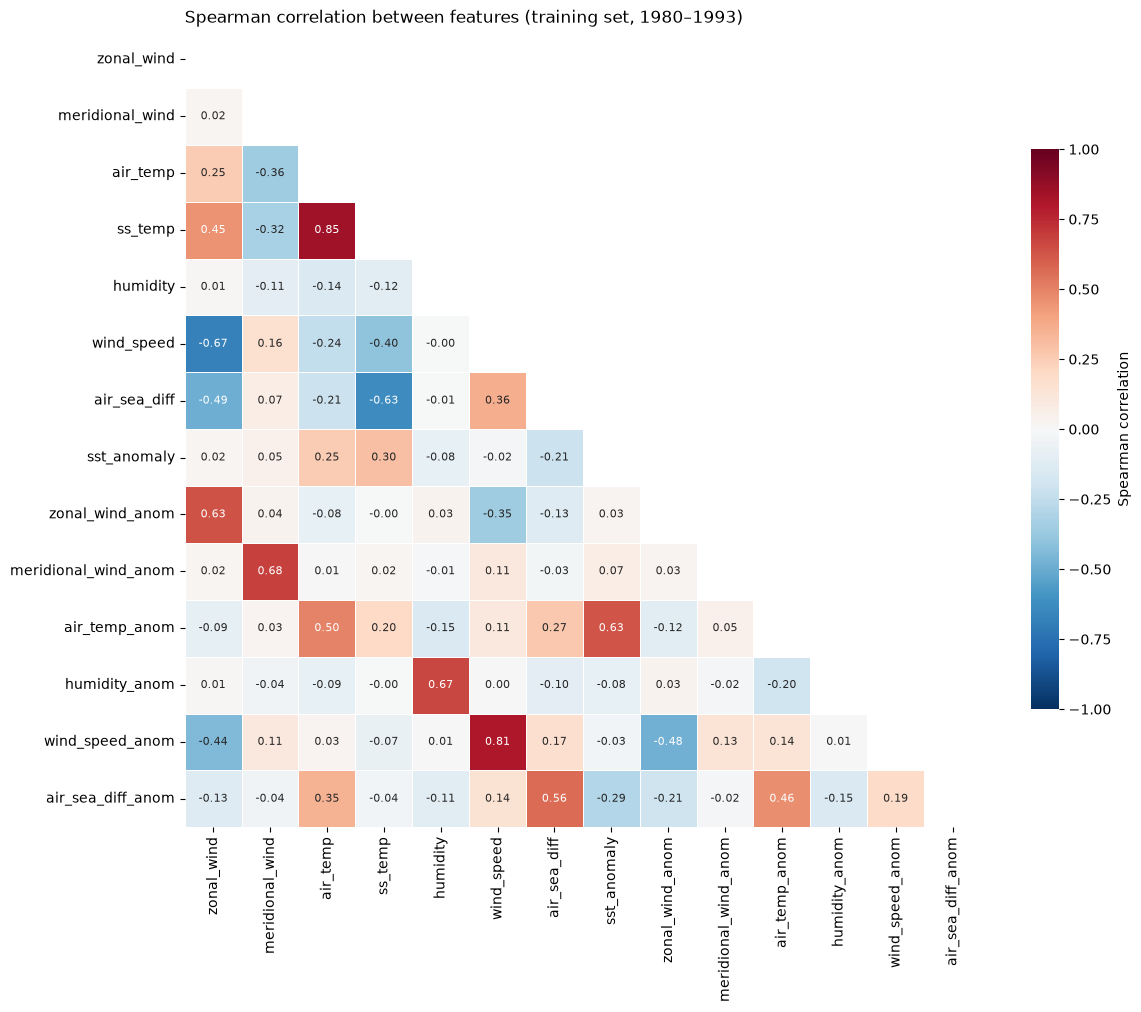

In [104]:
# Raw features, Step 3 features, and anomalies
CORR_COLS = [
    "zonal_wind", "meridional_wind", "air_temp", "ss_temp", "humidity",
    "wind_speed", "air_sea_diff",
    "sst_anomaly", "zonal_wind_anom", "meridional_wind_anom", "air_temp_anom",
    "humidity_anom", "wind_speed_anom", "air_sea_diff_anom",
]

corr = daily[CORR_COLS].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle + diagonal

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr, mask=mask,
    cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", annot_kws={"size": 8},
    linewidths=0.5, linecolor="white", square=True,
    cbar_kws={"label": "Spearman correlation", "shrink": 0.7},
    ax=ax,
)
ax.set_title("Spearman correlation between features (training set, 1980–1993)", loc="left")
plt.tight_layout()
plt.show()

In [105]:
# Strongest pairs, ranked by |r|
# k=1 drops the diagonal; stack() turns the grid into a list of pairs
pairs = (corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
             .stack()
             .sort_values(key=abs, ascending=False))
pairs.head(12).round(2)

air_temp         ss_temp                 0.85
wind_speed       wind_speed_anom         0.81
meridional_wind  meridional_wind_anom    0.68
zonal_wind       wind_speed             -0.67
humidity         humidity_anom           0.67
zonal_wind       zonal_wind_anom         0.63
sst_anomaly      air_temp_anom           0.63
ss_temp          air_sea_diff           -0.63
air_sea_diff     air_sea_diff_anom       0.56
air_temp         air_temp_anom           0.50
zonal_wind       air_sea_diff           -0.49
zonal_wind_anom  wind_speed_anom        -0.48
dtype: float64

### 4b. VIF (Variance Inflation Factor)
VIF asks: *how well can this feature be predicted from all the others?* It regresses each feature on the rest, then **VIF = 1 / (1 − R²)**.

| VIF | Meaning |
|---|---|
| 1 | Independent |
| 5 | 80% predictable: warning |
| 10+ | 90%+ predictable: seriously redundant |
| ∞ | An exact combination of other features |

Three sets are compared:
* **Set A:** raw variables.
* **Set B:** `air_sea_diff` instead of `air_temp` (the Part 3 fix).
* **Set C:** all three temperatures. `air_temp = ss_temp + air_sea_diff` exactly, so R² = 1 and VIF is infinite. It shows as ~1e15 with a `SingularMatrixWarning`, and that warning *is* the finding.

In [106]:
def compute_vif(cols):
    # dropna: regression can't handle NaN (with humidity, only 1989–1993 rows remain)
    # add_constant: adds an intercept; without it statsmodels gives wrong VIFs
    X = add_constant(daily[cols].dropna())
    vifs = [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]  # skip column 0, the constant
    return pd.Series(vifs, index=cols).round(1)

In [107]:
set_a = ["zonal_wind", "meridional_wind", "air_temp", "ss_temp", "humidity"]
set_b = ["zonal_wind", "meridional_wind", "ss_temp", "air_sea_diff", "humidity"]
set_c = ["zonal_wind", "meridional_wind", "air_temp", "ss_temp", "air_sea_diff"]

# NaN = feature not in that set
vif_table = pd.DataFrame({
    "Set A (raw)": compute_vif(set_a),
    "Set B (air_sea_diff instead of air_temp)": compute_vif(set_b),
    "Set C (all three temps)": compute_vif(set_c),
})
vif_table

/var/folders/jx/tblrw4j10ssbyrvsgwvsh64h0000gn/T/ipykernel_23488/301732654.py:5: UserWarning: The design matrix is poorly conditioned (condition number=6.17e+14). VIF calculations may be numerically unstable.
  vifs = [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]  # skip column 0, the constant
/Users/rina/Documents/vs-code/BTT_AWS1A/AWS-1A-climate-risk-modeling-for-supply-chain-resiliency/.venv/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/Users/rina/Documents/vs-code/BTT_AWS1A/AWS-1A-climate-risk-modeling-for-supply-chain-resiliency/.venv/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


,Set A (raw),Set B (air_sea_diff instead of air_temp),Set C (all three temps)
air_sea_diff,NaN,1.6,1.000800e+15
air_temp,4.9,NaN,1.000800e+15
humidity,1.0,1.0,NaN
meridional_wind,1.1,1.1,1.100000e+00
ss_temp,5.3,1.8,1.000800e+15
zonal_wind,1.3,1.3,1.200000e+00


### 4c. Findings

**Strongest pairs (Spearman):**
* `air_temp` ↔ `ss_temp` **0.85**: the expected near-duplicate (air over the ocean follows the water).
* Raw ↔ own anomaly, 0.50–0.81 (e.g. `wind_speed` ↔ `wind_speed_anom` 0.81): each anomaly still carries a lot of its raw variable.
* `zonal_wind` ↔ `wind_speed` **−0.67**: the trade winds dominate wind speed (stronger westward trades = more negative `u` = faster wind).
* `sst_anomaly` ↔ `air_temp_anom` **0.63**: unusual warm water comes with unusually warm air.
* Everything else is below 0.5.

**VIF:**
| Feature | Set A (raw) | Set B (swap) | Set C (all three) |
|---|---|---|---|
| `air_temp` | 4.8 | — | ∞ |
| `ss_temp` | 5.2 | 1.8 | ∞ |
| `air_sea_diff` | — | 1.6 | ∞ |
| winds, humidity | 1.0–1.3 | 1.0–1.3 | 1.1–1.2 |

**Decisions (provisional until Parts 5–6):**
1. **Drop `air_temp` from the model's feature list; keep `ss_temp` + `air_sea_diff`.** Swapping cuts the temperature VIFs from ~5 to under 2 and loses no information, since `air_temp = ss_temp + air_sea_diff`. `air_temp` stays in the cleaned data, because `air_sea_diff` and `air_temp_anom` are built from it. This result is for raw daily values; the forecast model uses monthly anomalies, where `air_temp_anom` is a strong predictor, so Parts 5–6 decide its fate there.
2. **Never include all three temperatures together.** Set C shows one is an exact combination of the other two (infinite VIF).
3. **Use one version per variable, raw or anomaly, not both.** Prefer the anomaly: it removes location and season, and the 3-month forecast features in `feature_engineering.ipynb` are anomalies.
4. **Keep `zonal_wind` and `wind_speed` for now.** −0.67 is "worth a look", not redundant; let mutual information (Part 6) decide whether `wind_speed` adds anything.

**Correlation vs. VIF:** `air_sea_diff`'s strongest pairwise correlation is only −0.63, yet its VIF in Set C is infinite. A heatmap only compares two features at a time, but `air_sea_diff` is predicted perfectly by **two features combined**. That's why both checks are needed.

## Part 5: Class Separation (Violin Plots)

A violin shows the full distribution of a feature for one class. **A useful feature shifts up or down as the classes go from cool to warm.** If all five violins look the same, the feature can't tell the classes apart.

* **5a. Today's class (daily):** how the physics works.
* **5b. Class 3 months ahead (monthly):** what the forecast model actually uses.

In [108]:
# Cool → warm, gray = Neutral (same order as CLASS_ORDER)
CLASS_COLORS = ["#184f95", "#5598e7", "#6b6a66", "#e66767", "#a82a2a"]

# Axis labels for the features plotted below
UNITS.update({
    "zonal_wind_anom": "Zonal wind anomaly (m/s)",
    "meridional_wind_anom": "Meridional wind anomaly (m/s)",
    "mer_wind_anom": "Meridional wind anomaly (m/s)",
    "wind_speed_anom": "Wind speed anomaly (m/s)",
    "air_temp_anom": "Air temperature anomaly (°C)",
    "air_sea_diff_anom": "Air–sea difference anomaly (°C)",
    "humidity_anom": "Humidity anomaly (%)",
    "ssta": "SST anomaly (°C)",
    "nino34_ssta": "Niño 3.4 SST anomaly (°C)",
})

# One function for both 5a and 5b
def violin_grid(df, features, class_col, title):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for col, ax in zip(features, axes):
        # One list of values per class, in cool → warm order
        data = [df.loc[df[class_col] == c, col].dropna() for c in CLASS_ORDER]

        # quantiles draws the 25th / 50th / 75th percentile lines inside each violin
        parts = ax.violinplot(data, positions=range(len(CLASS_ORDER)),
                              quantiles=[[0.25, 0.5, 0.75]] * len(CLASS_ORDER), showextrema=False)
        for body, color in zip(parts["bodies"], CLASS_COLORS):
            body.set_facecolor(color)
            body.set_alpha(0.85)
        parts["cquantiles"].set_color("white")

        if "anom" in col or col.endswith("ssta"):
            ax.axhline(0, color="#b5b3ad", linewidth=0.8, zorder=0)  # 0 = normal for an anomaly
        ax.set_xticks(range(len(CLASS_ORDER)), CLASS_ORDER, rotation=30)
        ax.set_title(col, loc="left")
        ax.set_ylabel(UNITS[col])
        ax.spines[["top", "right"]].set_visible(False)

    for ax in axes[len(features):]:  # hide unused slots
        ax.axis("off")

    fig.suptitle(title, x=0.01, ha="left", fontsize=14)
    plt.tight_layout()
    plt.show()

### 5a. Today's Class (Daily)
`sst_anomaly` is left out since the class is defined from it.

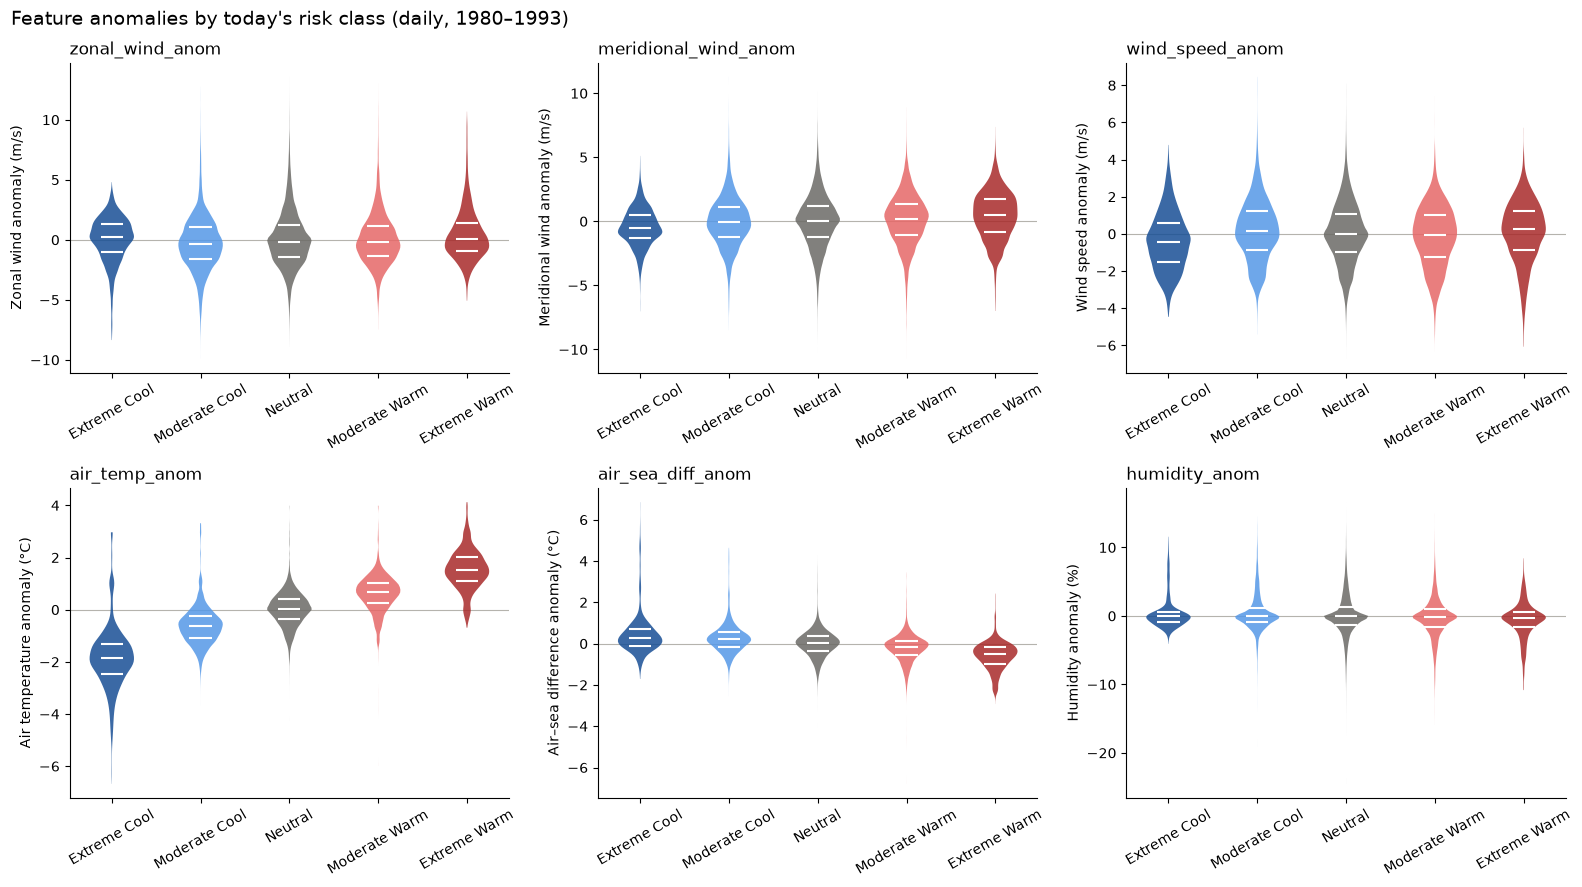

,zonal_wind_anom,meridional_wind_anom,wind_speed_anom,air_temp_anom,air_sea_diff_anom,humidity_anom
risk_class,,,,,,
Extreme Cool,0.22,-0.52,-0.43,-1.87,0.26,0.00
Moderate Cool,-0.37,-0.08,0.18,-0.64,0.20,-0.04
Neutral,-0.14,0.06,0.00,0.03,0.03,-0.07
Moderate Warm,-0.21,0.22,-0.06,0.67,-0.16,-0.16
Extreme Warm,0.09,0.52,0.26,1.53,-0.52,-0.34


In [109]:
DAILY_VIOLIN = ["zonal_wind_anom", "meridional_wind_anom", "wind_speed_anom",
                "air_temp_anom", "air_sea_diff_anom", "humidity_anom"]

violin_grid(daily, DAILY_VIOLIN, "risk_class", "Feature anomalies by today's risk class (daily, 1980–1993)")

# Median per class: the numbers behind the plots
daily.groupby("risk_class", observed=True)[DAILY_VIOLIN].median().round(2)

### 5b. Class 3 Months Ahead (Monthly)
Here `ssta` is fair to include: it's *today's* anomaly, compared against the class *3 months later*.

**Where the monthly features come from:** `features-train.csv` is built by `feature_engineering.ipynb` (see `docs/FORECAST_FEATURES.md`), not this notebook. That includes the basin-wide features:
* `basin_ssta`, `basin_zwind_anom`: average SST / zonal wind anomaly across **all buoys** that month (one value per month, shared by every site).
* `nino34_ssta`: average SST anomaly in the Niño 3.4 box (5°S–5°N, 170°W–120°W), the region NOAA uses to declare El Niño. `nino34_ssta_roll3` is its 3-month rolling mean.

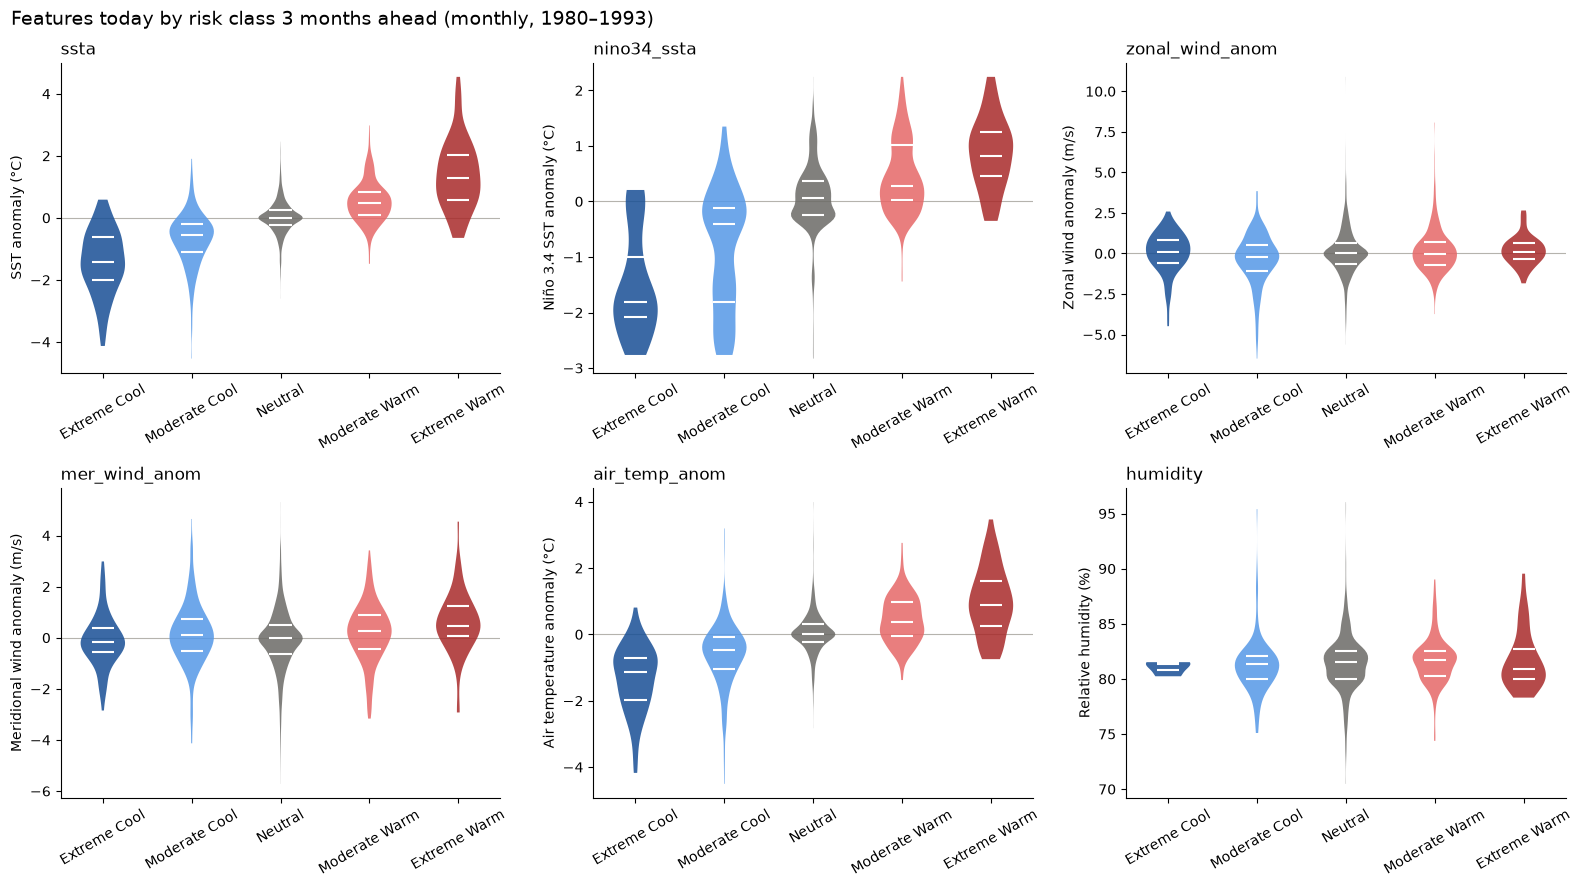

,ssta,nino34_ssta,zonal_wind_anom,mer_wind_anom,air_temp_anom,humidity
target_risk,,,,,,
Extreme Cool,-1.42,-1.81,0.09,-0.18,-1.13,81.37
Moderate Cool,-0.57,-0.40,-0.19,0.10,-0.47,81.37
Neutral,0.00,0.05,0.00,-0.00,0.00,81.51
Moderate Warm,0.47,0.28,-0.02,0.25,0.37,81.69
Extreme Warm,1.30,0.82,0.12,0.47,0.88,80.91


In [110]:
MONTHLY_VIOLIN = ["ssta", "nino34_ssta", "zonal_wind_anom",
                  "mer_wind_anom", "air_temp_anom", "humidity"]

violin_grid(monthly, MONTHLY_VIOLIN, "target_risk", "Features today by risk class 3 months ahead (monthly, 1980–1993)")

monthly.groupby("target_risk", observed=True)[MONTHLY_VIOLIN].median().round(2)

### 5c. Findings

| Feature | Today's class (daily) | Class 3 months ahead (monthly) |
|---|---|---|
| `air_temp_anom` | **Strong**: medians −1.87 → +1.53 °C | **Strong**: −1.13 → +0.88 °C |
| `ssta` / `nino34_ssta` | (defines the class) | **Strong**: −1.42 → +1.30 / −1.81 → +0.82 °C |
| `air_sea_diff_anom` | Moderate: +0.26 → −0.52 °C (air lags behind warming water) | (not in monthly file) |
| `meridional_wind_anom` | Weak: −0.52 → +0.52 m/s | Weak: −0.18 → +0.47 m/s |
| `zonal_wind_anom` | None | None |
| `wind_speed_anom`, humidity | None | None |

**Takeaways:**
* **Temperature anomalies carry the signal**, both today and 3 months ahead. `air_temp_anom` clearly separates the forecast classes, so it **stays** in the forecast model (this answers the open question from Part 4).
* **Local zonal wind doesn't separate the classes**, even though weakened trade winds drive El Niño. Likely reason: the wind signal is basin-wide and leads SST by months, so one buoy's same-month wind misses it. Part 7 (Hovmöller) and the basin-wide wind feature will test this.
* **Extreme classes are small** in the monthly data (66 Extreme Warm, 90 Extreme Cool), so their violins are rougher. Monthly humidity for Extreme Cool is especially thin because pre-1989 humidity is missing.

## Part 6: Mutual Information

Mutual information (MI) measures **how much knowing a feature reduces uncertainty about the class**. 0 = no information.
* **Why not just correlation?** Correlation only sees straight-line relationships. MI also catches curved or threshold effects (e.g. a feature that matters only at extremes).
* **Data:** monthly features vs. the class **3 months ahead**, since that's what the model predicts.
* **Noise baseline:** a column of random numbers is added. Any feature scoring near it carries no real information.

In [111]:
# Every model feature in the monthly file (ids, targets, and the noise column left out)
NOT_FEATURES = ["site_id", "ym", "year", "month", "current_risk", "target_ssta", "target_risk", "random_noise"]
MI_FEATURES = [c for c in monthly.columns if c not in NOT_FEATURES]

# Noise baseline: random numbers with no link to the class
rng = np.random.default_rng(42)
monthly["random_noise"] = rng.normal(size=len(monthly))

rows = []
for col in MI_FEATURES + ["random_noise"]:
    # MI can't handle NaN, so score each feature on its own non-missing rows
    sub = monthly[[col, "target_risk", "target_ssta"]].dropna()
    mi = mutual_info_classif(sub[[col]], sub["target_risk"], random_state=42)[0]
    rho = sub[col].corr(sub["target_ssta"], method="spearman")  # for comparison
    rows.append({"feature": col, "mi": mi, "spearman_vs_target_ssta": rho, "rows_used": len(sub)})

mi_table = pd.DataFrame(rows).sort_values("mi", ascending=False).reset_index(drop=True)
noise_mi = mi_table.loc[mi_table["feature"] == "random_noise", "mi"].item()
mi_table.round(3)

,feature,mi,spearman_vs_target_ssta,rows_used
0,nino34_ssta_roll3,0.294,0.438,1944
1,basin_ssta,0.294,0.506,1988
2,nino34_ssta,0.285,0.469,1946
3,basin_zwind_anom,0.273,0.324,1988
4,ssta,0.225,0.602,1988
5,ssta_roll3,0.200,0.532,1879
6,air_temp_anom,0.197,0.483,1988
7,ssta_lag1,0.168,0.500,1865
8,ssta_roll6,0.159,0.425,1913
9,air_temp_anom_lag1,0.144,0.407,1865


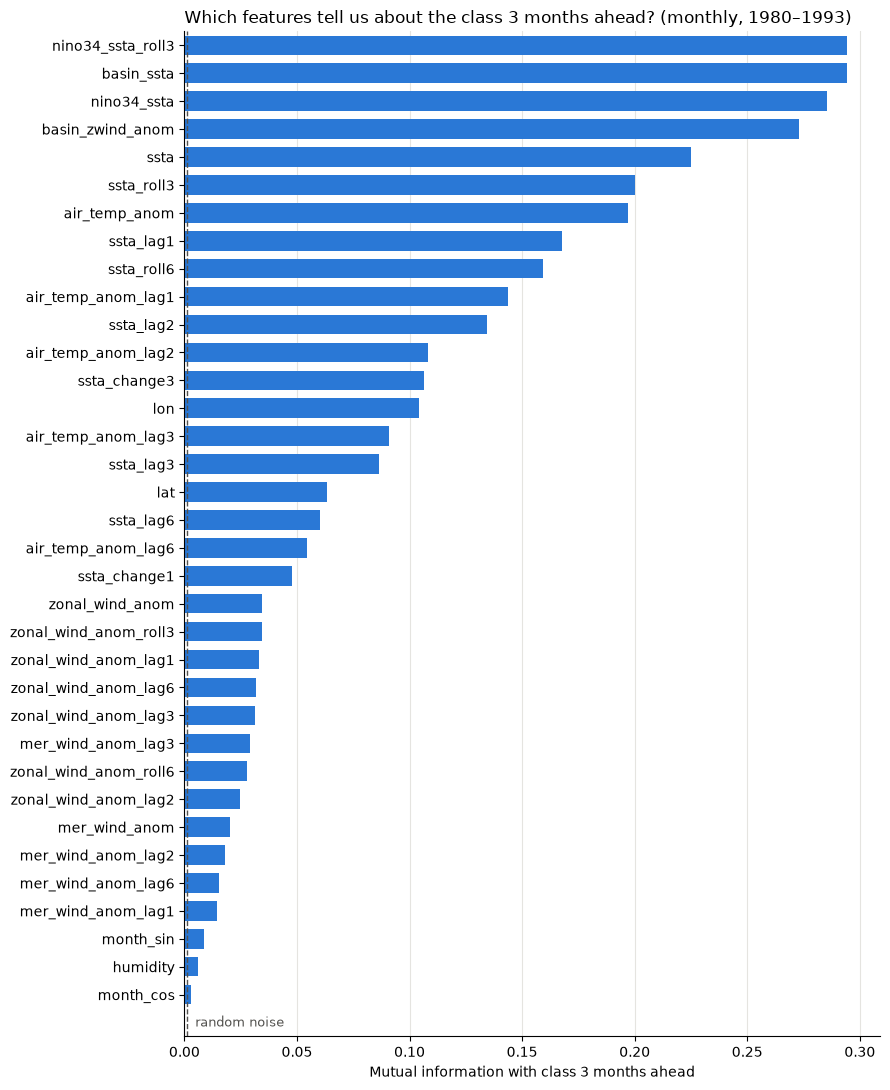

In [112]:
# Horizontal bars: long feature names stay readable; highest MI at the top
plot_df = mi_table[mi_table["feature"] != "random_noise"].iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 11))
ax.barh(plot_df["feature"], plot_df["mi"], color="#2a78d6", height=0.7)

# Noise baseline, labelled below the bars so it doesn't cover them
ax.axvline(noise_mi, color="#52514e", linestyle="--", linewidth=1)
ax.set_ylim(-1.5, len(plot_df) - 0.5)
ax.text(noise_mi, -1, "  random noise", color="#52514e", va="center", fontsize=9)

ax.set_xlabel("Mutual information with class 3 months ahead")
ax.set_title("Which features tell us about the class 3 months ahead? (monthly, 1980–1993)", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e5e4e0", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 6a. Findings

| Tier | Features | MI |
|---|---|---|
| **Top** | `nino34_ssta_roll3`, `basin_ssta`, `nino34_ssta`, `basin_zwind_anom` | 0.27–0.29 |
| **Strong** | `ssta`, `ssta_roll3`, `air_temp_anom`, `ssta_lag1`, `ssta_roll6`, `air_temp_anom_lag1` | 0.14–0.23 |
| **Moderate** | longer SST / air-temp lags, `ssta_change3`, `lon`, `lat` | 0.05–0.14 |
| **Weak** | local wind anomalies (zonal + meridional, all lags) | 0.01–0.04 |
| **≈ Noise** | `month_sin`, `month_cos`, `humidity` | < 0.01 (noise = 0.001) |

**Takeaways:**
* **The wind signal is basin-wide, as Part 5 suspected.** `basin_zwind_anom` ranks 4th (0.27), while every local zonal wind feature is near the bottom (~0.03).
* **Basin-wide features win overall.** El Niño is basin-scale, so one buoy sees only part of it. Caveat: a basin feature has one value per month (143 unique values) shared by all sites, so its MI partly reflects *which month* it is. Still real signal, but likely somewhat inflated.
* **MI catches what correlation misses:** `lon` has MI 0.10 but Spearman −0.02. Location matters, just not in a straight line (east vs. west Pacific behave differently).
* **POTENTIALLY Drop candidates:** `humidity`, `month_sin`, `month_cos` score at noise level. Not final! -> MI checks one feature at a time and can't see interactions (e.g. season × SST), so confirm with model feature importance first.

## Part 7: Wind Deep-Dive

Parts 5–6 showed the zonal wind signal is basin-wide, not local. This part looks at it across space and time.
* **7a. Hovmöller diagram:** longitude (x) × time (y), colored by anomaly, along the equator. Wind and SST side by side, so you can see whether the wind changes first.
* **7b. Lead time:** how many months ahead does the wind anomaly predict the Niño 3.4 SST anomaly?

**Sign reminder:** positive zonal wind anomaly = weaker trade winds (or winds reversing to blow east). That's the El Niño trigger.

### 7a. Hovmöller Diagram
* **Equatorial band only** (2°S–2°N): El Niño's wind and warm water travel along the equator.
* **Longitude in 0–360°E**, so the Pacific isn't split at the Date Line (180°).
* **Missing months stay gray**, so gaps aren't mistaken for "normal" (white).

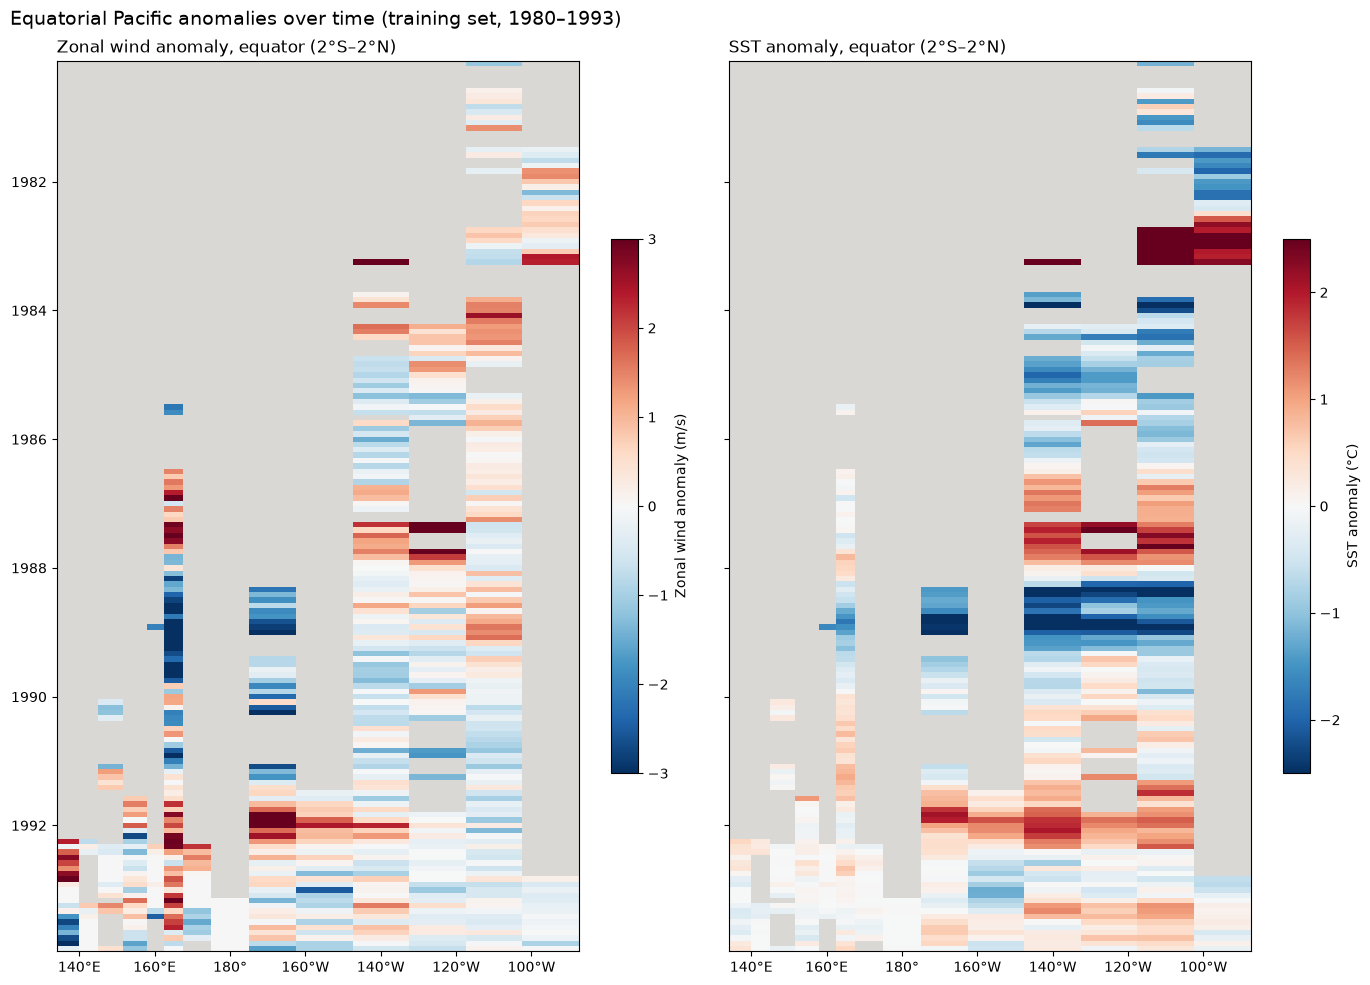

In [113]:
daily["ym"] = daily["standardized_date"].dt.to_period("M").dt.to_timestamp()  # first day of each month
daily["lon_east"] = daily["nominal_lon"] % 360  # e.g. -140 (140°W) becomes 220
ALL_MONTHS = pd.date_range(daily["ym"].min(), daily["ym"].max(), freq="MS")

eq = daily[daily["nominal_lat"].between(-2, 2)]

def hovmoller(col):
    # One row per month, one column per longitude; reindex adds empty rows for missing months
    return (eq.pivot_table(index="ym", columns="lon_east", values=col, aggfunc="mean")
              .reindex(ALL_MONTHS))

hov_wind = hovmoller("zonal_wind_anom")
hov_sst = hovmoller("sst_anomaly")

LON_TICKS = [140, 160, 180, 200, 220, 240, 260]
LON_LABELS = ["140°E", "160°E", "180°", "160°W", "140°W", "120°W", "100°W"]

fig, axes = plt.subplots(1, 2, figsize=(14, 10), sharey=True)
panels = [
    (hov_wind, "Zonal wind anomaly", "m/s", 3),   # ±3: covers ~98% of values
    (hov_sst, "SST anomaly", "°C", 2.5),
]
for ax, (data, name, unit, lim) in zip(axes, panels):
    mesh = ax.pcolormesh(data.columns, data.index, data.values, shading="nearest",
                         cmap="RdBu_r", vmin=-lim, vmax=lim)
    fig.colorbar(mesh, ax=ax, label=f"{name} ({unit})", shrink=0.6)
    ax.set_facecolor("#d9d8d4")  # gray = no data
    ax.set_xticks(LON_TICKS, LON_LABELS)
    ax.set_title(f"{name}, equator (2°S–2°N)", loc="left")

axes[0].invert_yaxis()  # time runs top to bottom (shared by both panels)
fig.suptitle("Equatorial Pacific anomalies over time (training set, 1980–1993)", x=0.01, ha="left", fontsize=14)
plt.tight_layout()
plt.show()

### 7b. Lead Time
Two monthly series:
* **Wind:** zonal wind anomaly in the western Pacific on the equator (140°E–180°), where wind bursts start.
* **SST:** SST anomaly in the Niño 3.4 box (5°S–5°N, 170°W–120°W).

We shift the wind series by *k* months and correlate. **Positive k = wind comes first.** If the correlation peaks at a positive k, the wind is an early warning.

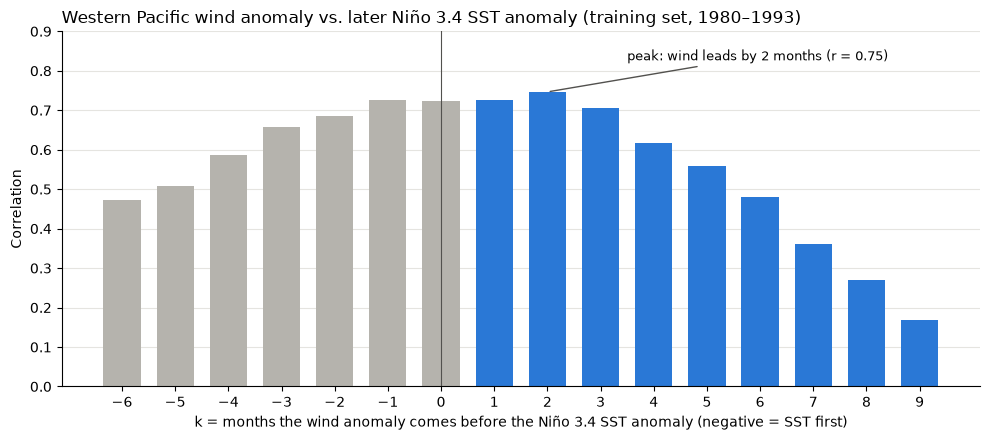

-6    0.47
-5    0.51
-4    0.59
-3    0.66
-2    0.68
-1    0.72
0     0.72
1     0.73
2     0.75
3     0.70
4     0.62
5     0.56
6     0.48
7     0.36
8     0.27
9     0.17
dtype: float64

In [114]:
west_wind = (eq[eq["lon_east"].between(140, 180)]
             .groupby("ym")["zonal_wind_anom"].mean().reindex(ALL_MONTHS))
nino34 = (daily[daily["nominal_lat"].between(-5, 5) & daily["lon_east"].between(190, 240)]
          .groupby("ym")["sst_anomaly"].mean().reindex(ALL_MONTHS))

# shift(k) moves the wind k months later, so it lines up with SST k months after it happened
LAGS = range(-6, 10)
lead_corr = pd.Series({k: nino34.corr(west_wind.shift(k)) for k in LAGS})

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#2a78d6" if k > 0 else "#b5b3ad" for k in LAGS]  # blue = wind leads
ax.bar(list(LAGS), lead_corr.values, color=colors, width=0.7)
ax.axvline(0, color="#52514e", linewidth=0.8)
best = lead_corr.idxmax()
ax.annotate(f"peak: wind leads by {best} months (r = {lead_corr[best]:.2f})",
            xy=(best, lead_corr[best]), xytext=(best + 1.5, lead_corr[best] + 0.08),
            arrowprops=dict(arrowstyle="-", color="#52514e"), fontsize=9)

ax.set_xticks(list(LAGS))
ax.set_xlabel("k = months the wind anomaly comes before the Niño 3.4 SST anomaly (negative = SST first)")
ax.set_ylabel("Correlation")
ax.set_ylim(0, 0.9)
ax.set_title("Western Pacific wind anomaly vs. later Niño 3.4 SST anomaly (training set, 1980–1993)", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

lead_corr.round(2)

### 7c. Findings

**Hovmöller (7a):**
* **The buoy array was still being built during training.** Before ~1986 only a few eastern buoys report; the western Pacific (140°E–180°) has data from mid-1986 on. Gray areas are missing data, not calm conditions.
* **Known events are visible in SST:** 1982–83 El Niño (dark red near 110°W), 1987 El Niño (red, 140°W–110°W), 1988–89 La Niña (dark blue across the east), 1991–92 El Niño (red from 180° eastward).
* **Wind and SST anomalies line up:** red wind bands (weakened trades) coincide with or come just before red SST bands in the same longitudes, e.g. 1987 and 1991–92.

**Lead time (7b):**
* Western Pacific wind anomaly vs. Niño 3.4 SST anomaly: **r = 0.72 at the same month, peaking at r = 0.75 when the wind leads by 2 months**, and still **0.70 at 3 months ahead**, our forecast horizon.
* Correlation is also high when SST comes first (0.66 at −3). Wind and SST reinforce each other (a feedback loop), so the 2-month peak is a modest edge, not proof of cause.
* Based on 92 months of western wind data, and monthly anomalies change slowly, so treat the exact peak month as approximate.

**Takeaways:**
* **Keep `basin_zwind_anom`, and consider a western-Pacific wind feature** (zonal wind anomaly averaged over 140°E–180° on the equator). It holds r ≥ 0.70 up to 3 months ahead, the same horizon the model forecasts.
* **Local zonal wind is weak because it's measured in the wrong place:** the early-warning wind is in the *west*, while most El Niño warming shows up in the *east*. A buoy's own wind doesn't capture the basin-wide pattern.

## Part 8: Wrap-Up (Final Feature List)

Turns Parts 1–7 into a keep / add / drop list for the forecast model (`FEATURES` in `feature_engineering.ipynb`). Two last checks first:
* **8a.** Do the two new candidate features help forecast the class 3 months ahead?
* **8b.** Are the top monthly features redundant with each other? (Part 4 only checked the daily data.)

In [115]:
# 8a. Candidate 1: western Pacific wind (Part 7), one value per month shared by every site
west = west_wind.copy()
west.index = west.index.to_period("M").astype(str)  # match monthly["ym"] format, e.g. "1985-06"
monthly["west_pac_zwind_anom"] = monthly["ym"].map(west)

# Candidate 2: air–sea difference anomaly (Part 3), averaged per site and month
asd = (daily.groupby(["site_id", daily["ym"].dt.to_period("M").astype(str)])["air_sea_diff_anom"]
            .mean().rename("air_sea_diff_anom"))
asd.index.names = ["site_id", "ym"]
monthly = (monthly.drop(columns=["air_sea_diff_anom"], errors="ignore")  # safe to rerun
                  .merge(asd.reset_index(), on=["site_id", "ym"], how="left"))

# Same scoring as Part 6, with the existing wind features for comparison
rows = []
for col in ["west_pac_zwind_anom", "basin_zwind_anom", "air_sea_diff_anom", "zonal_wind_anom"]:
    sub = monthly[[col, "target_risk", "target_ssta"]].dropna()
    rows.append({
        "feature": col,
        "mi": mutual_info_classif(sub[[col]], sub["target_risk"], random_state=42)[0],
        "spearman_vs_target_ssta": sub[col].corr(sub["target_ssta"], method="spearman"),
        "rows_used": len(sub),
    })
pd.DataFrame(rows).round(3)

,feature,mi,spearman_vs_target_ssta,rows_used
0,west_pac_zwind_anom,0.282,0.413,1878
1,basin_zwind_anom,0.273,0.324,1988
2,air_sea_diff_anom,0.042,-0.157,1988
3,zonal_wind_anom,0.035,0.079,1988


In [116]:
# 8b. Redundancy among the top monthly features (same ranking as Part 4a)
TOP = ["nino34_ssta_roll3", "nino34_ssta", "basin_ssta", "ssta", "ssta_roll3", "ssta_lag1",
       "ssta_roll6", "air_temp_anom", "air_temp_anom_lag1", "basin_zwind_anom", "west_pac_zwind_anom"]
top_corr = monthly[TOP].corr(method="spearman")
top_pairs = (top_corr.where(np.triu(np.ones_like(top_corr, dtype=bool), k=1))
                     .stack()
                     .sort_values(key=abs, ascending=False))
top_pairs[top_pairs.abs() >= 0.7].round(2)

ssta_roll3         ssta_lag1              0.95
nino34_ssta        basin_ssta             0.95
nino34_ssta_roll3  nino34_ssta            0.94
                   basin_ssta             0.93
ssta_roll3         ssta_roll6             0.92
ssta               ssta_roll3             0.91
ssta_lag1          ssta_roll6             0.88
ssta               ssta_lag1              0.83
air_temp_anom      air_temp_anom_lag1     0.82
ssta               ssta_roll6             0.79
basin_zwind_anom   west_pac_zwind_anom    0.75
ssta_lag1          air_temp_anom_lag1     0.73
ssta               air_temp_anom          0.72
ssta_roll3         air_temp_anom_lag1     0.71
dtype: float64

### 8c. Final Feature List

**8a:** `west_pac_zwind_anom` is the best wind feature (MI 0.28, Spearman 0.41 vs. 0.27 / 0.32 for `basin_zwind_anom`). `air_sea_diff_anom` doesn't help forecast (MI 0.04).
**8b:** the top SST features are near-duplicates (r 0.83–0.95). Fine for accuracy, but they will split importance in SHAP plots.

| Decision | Features | Evidence |
|---|---|---|
| **Add** | `west_pac_zwind_anom` (equatorial zonal wind anomaly, 140°E–180°) | Highest-MI wind feature; r ≥ 0.70 with Niño 3.4 SST up to 3 months ahead (Parts 7, 8a) |
| **Keep** (20) | SST: `ssta`, `ssta_lag1/2/3/6`, `ssta_roll3/6`, `ssta_change1/3` · Basin: `basin_ssta`, `nino34_ssta`, `nino34_ssta_roll3`, `basin_zwind_anom` · Air temp: `air_temp_anom`, `air_temp_anom_lag1/2/3/6` · Location: `lat`, `lon` | Top MI tiers and clear class separation (Parts 5–6); `lat`/`lon` nonlinear (Part 6) |
| **Keep, current value only** (2) | `zonal_wind_anom`, `mer_wind_anom` | Weak but above noise (Part 6) |
| **Trim candidates** (10) | Lags and rolling means of local wind: `zonal_wind_anom_lag1/2/3/6`, `_roll3/6`, `mer_wind_anom_lag1/2/3/6` | MI 0.01–0.04; with ~2,000 training rows, near-useless columns add overfitting risk |
| **Drop candidates** (3) | `humidity`, `month_sin`, `month_cos` | MI at noise level (Part 6) |
| **Don't add** | `air_sea_diff_anom`, `wind_speed_anom`, `wind_dir_to` | No forecast signal (8a), no class separation (5a), circular (3b) |

Result: **35 → 23 features** if all trims and drops are confirmed.